In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

df = pd.read_csv("car_evaluation.csv", header=None)
df.columns = ["buying","maint","doors","persons","lug_boot","safety","class"]

df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## ตรวจสอบข้อมูลเบื้องต้น


In [3]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB
None

Missing values:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


## Exploratory Data Analysis (EDA)


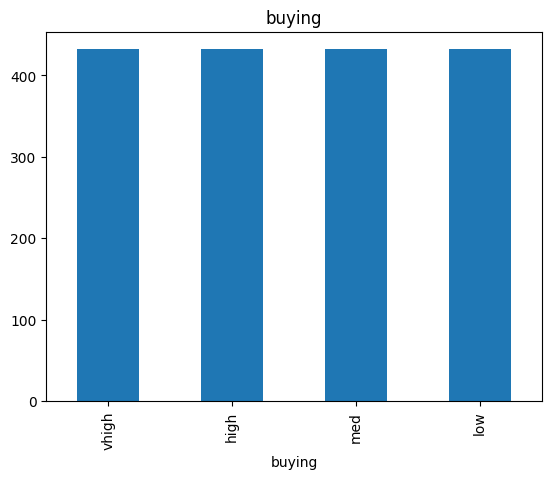

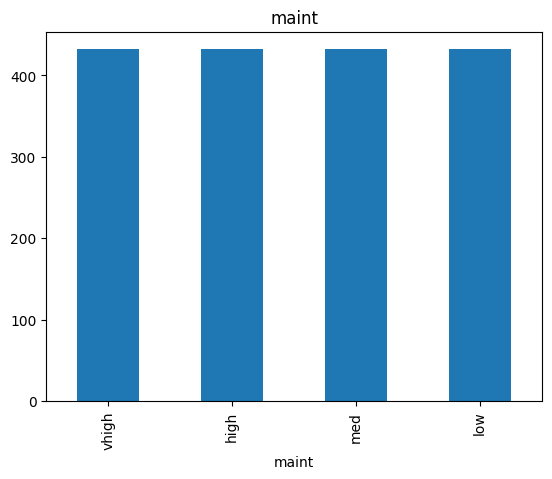

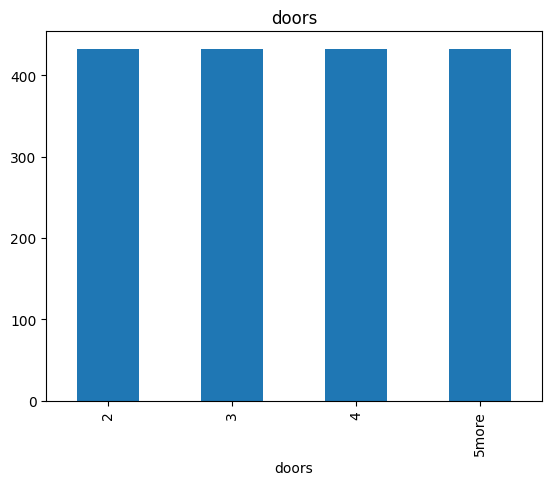

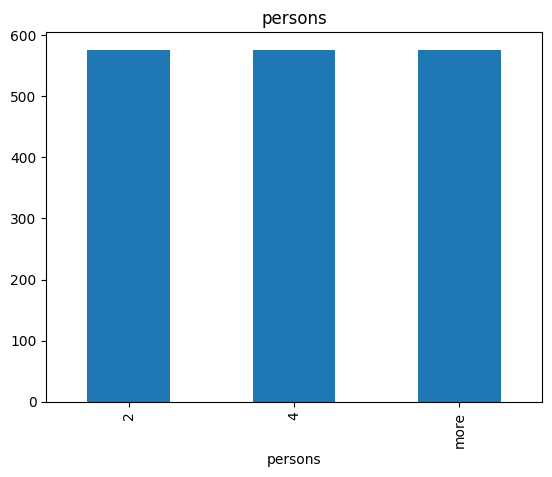

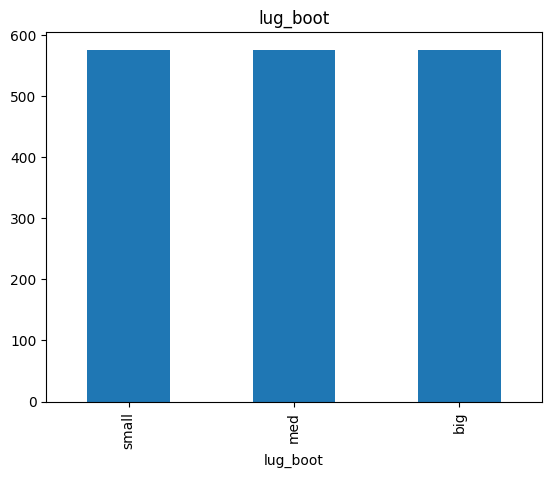

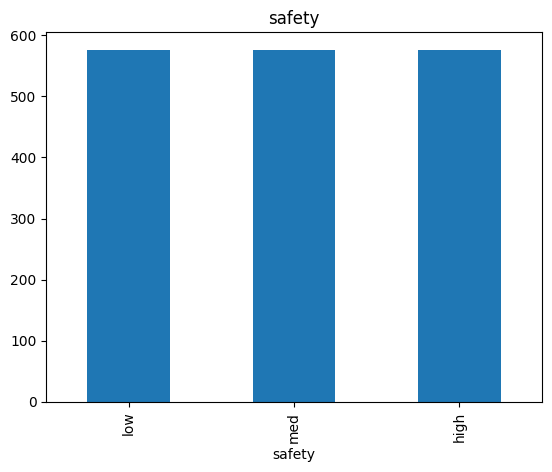

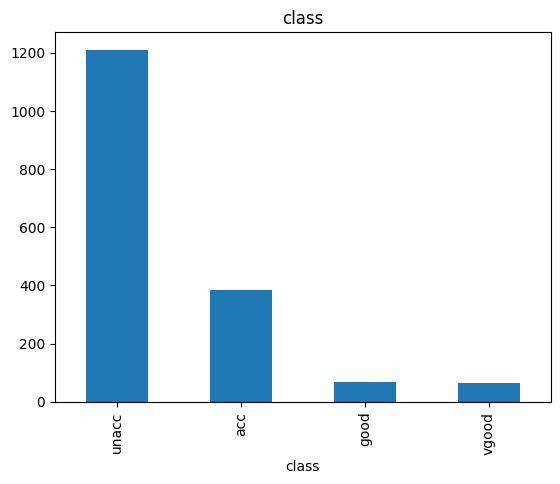

In [4]:
for col in df.columns:
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

## Data Preprocessing



In [5]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

## แบ่งข้อมูล Train / Test

In [7]:
X = df.drop("class", axis=1)
y = df["class"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## สร้างโมเดล (Random Forest)

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

##ประเมินผล

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.90      0.94        83
           1       0.65      1.00      0.79        11
           2       0.99      1.00      1.00       235
           3       1.00      0.94      0.97        17

    accuracy                           0.97       346
   macro avg       0.91      0.96      0.92       346
weighted avg       0.98      0.97      0.98       346


Confusion Matrix:
[[ 75   6   2   0]
 [  0  11   0   0]
 [  0   0 235   0]
 [  1   0   0  16]]


##Cross Validation

In [10]:
from sklearn.model_selection import cross_val_score

cv_score = cross_val_score(model, X, y, cv=5)
print("CV Score:", cv_score.mean())

CV Score: 0.8154594956856831


## Hyperparameter Tuning

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

best_model = grid.best_estimator_

Best params: {'max_depth': None, 'n_estimators': 100}


## ประเมินผลหลัง tuning

In [12]:
pred2 = best_model.predict(X_test)

print("After tuning:")
print(classification_report(y_test, pred2))

After tuning:
              precision    recall  f1-score   support

           0       0.99      0.89      0.94        83
           1       0.65      1.00      0.79        11
           2       0.99      1.00      0.99       235
           3       1.00      0.94      0.97        17

    accuracy                           0.97       346
   macro avg       0.91      0.96      0.92       346
weighted avg       0.98      0.97      0.97       346



## Save Model


In [14]:
joblib.dump(best_model, "model.pkl")
joblib.dump(le_dict, "encoders.pkl")

print("Save model เรียบร้อย")

Save model เรียบร้อย
